# AlphaZero Self-Play Training

Este notebook é o cockpit de treino e experimentação do `AlphaZero`. Serve para lançar corridas, analisar métricas, comparar checkpoints e iterar na configuração principal. Para demonstrar o melhor modelo treinado, usa o `06_alphazero_best_model_showcase.ipynb`.


## Objetivo

O objetivo deste notebook é:

- lançar treino `AlphaZero` usando os módulos de `connect4_rl`;
- analisar checkpoints guardados;
- medir evolução contra baselines e contra snapshots anteriores;
- acompanhar a métrica tática de jogadas imediatas de vitória ou bloco;
- usar este notebook como base de iteração para novos testes.


## Passo 1: Preparação do ambiente

Importamos o código do projeto, os baselines, o agente `AlphaZero`, as utilidades gráficas e a pasta `outputs/`.

A implementação usada aqui vive agora principalmente em:

- `connect4_rl/agents/learning/alphazero.py`;
- `connect4_rl/experiments/alphazero_training.py`;
- `connect4_rl/envs/connect_four.py`.


In [1]:
from __future__ import annotations

import json
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().resolve()
while not (ROOT / "config.yaml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "config.yaml").exists():
    raise FileNotFoundError("Could not find project root containing config.yaml")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS = ROOT / "outputs"
ALPHAZERO_OUTPUTS = ROOT / "notebooks" / "alphazero" / "outputs"
ALPHAZERO_OUTPUTS.mkdir(parents=True, exist_ok=True)

from connect4_rl.config import load_config
CONFIG = load_config(ROOT / "config.yaml")

NOTEBOOK_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if NOTEBOOK_DEVICE == "cuda":
    torch.set_default_device(NOTEBOOK_DEVICE)
print(
    {
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_device_count": torch.cuda.device_count(),
        "device": NOTEBOOK_DEVICE,
        "cuda_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
)
ALPHAZERO_OUTPUTS

from connect4_rl.agents.baselines import HeuristicAgent, RandomAgent
from connect4_rl.agents.learning import AlphaZeroConfig
from connect4_rl.envs.connect_four import apply_action, initial_state, is_terminal, legal_actions, render_ascii
from connect4_rl.experiments import build_agent_from_checkpoint, build_agent_from_run, compute_elo_ratings, find_best_run, round_robin_detailed
from connect4_rl.experiments.alphazero_training import train_alphazero_self_play


✓ Configuration validated successfully
{'torch_version': '2.11.0+cu130', 'cuda_available': True, 'cuda_device_count': 1, 'device': 'cuda', 'cuda_name': 'NVIDIA GeForce RTX 5060 Laptop GPU'}


## Passo 2: Configuração do treino de AlphaZero

Nesta célula definimos o comportamento principal do notebook. Tal como no DQN, tens um perfil `quick` para iteração rápida e um perfil `full` viável para treino real, mantendo a lógica do AlphaZero mas com custo muito mais razoável do que o regime pesado do tutorial.

- `train_from_notebook`: se estiver a `True`, o notebook lança um novo treino.
- `run_checkpoint_elo`: se estiver a `True`, o notebook organiza um torneio entre checkpoints do mesmo treino.
- `training_profile`: escolhe entre `quick` e `full`.
- `training_config`: concentra os hiperparâmetros principais do `AlphaZero` integrado no projeto.


In [2]:
train_from_notebook = True
run_checkpoint_elo = True
training_profile = "full"  # "quick" or "full"

seed = CONFIG.notebook_settings.seed

profile_settings = {
    "quick": {
        "episodes": CONFIG.notebook_settings.quick_test_episodes,
        "eval_interval": CONFIG.notebook_settings.quick_test_eval_interval,
        "eval_games": CONFIG.notebook_settings.quick_test_eval_games,
        "mcts_simulations": CONFIG.notebook_settings.quick_test_mcts_simulations,
        "eval_mcts_simulations": CONFIG.notebook_settings.quick_test_eval_mcts_simulations,
        "n_filters": 128,
        "n_res_blocks": 4,
        "updates_per_episode": 1,
        "replay_warmup_games": 12,
        "tactical_eval_examples": 64,
    },
    "full": {
        "episodes": CONFIG.alphazero.episodes,
        "eval_interval": CONFIG.alphazero.eval_interval,
        "eval_games": CONFIG.alphazero.eval_games,
        "mcts_simulations": CONFIG.alphazero.mcts_simulations,
        "eval_mcts_simulations": CONFIG.alphazero.eval_mcts_simulations,
        "n_filters": CONFIG.alphazero.n_filters,
        "n_res_blocks": CONFIG.alphazero.n_res_blocks,
        "updates_per_episode": CONFIG.alphazero.updates_per_episode,
        "replay_warmup_games": CONFIG.alphazero.replay_warmup_games,
        "tactical_eval_examples": CONFIG.alphazero.tactical_eval_examples,
    },
}

settings = profile_settings[training_profile]
training_config = AlphaZeroConfig(
    **{
        **CONFIG.alphazero.__dict__,
        **settings,
        "seed": seed,
        "device": NOTEBOOK_DEVICE,
    }
)

run_name = f"alphazero_self_play_{training_profile}_seed_{training_config.seed}"
checkpoint_dir = ALPHAZERO_OUTPUTS / run_name
{
    "run_name": run_name,
    "checkpoint_dir": str(checkpoint_dir),
    "training_profile": training_profile,
    "episodes": training_config.episodes,
    "learning_rate": training_config.learning_rate,
    "batch_size": training_config.batch_size,
    "mcts_simulations": training_config.mcts_simulations,
    "mcts_start_search_iter": training_config.mcts_start_search_iter,
    "mcts_max_search_iter": training_config.mcts_max_search_iter,
    "mcts_search_increment": training_config.mcts_search_increment,
    "eval_mcts_simulations": training_config.eval_mcts_simulations,
    "n_filters": training_config.n_filters,
    "n_res_blocks": training_config.n_res_blocks,
    "temperature": training_config.temperature,
    "dirichlet_alpha": training_config.dirichlet_alpha,
    "dirichlet_epsilon": training_config.dirichlet_epsilon,
    "updates_per_episode": training_config.updates_per_episode,
}

{'run_name': 'alphazero_self_play_full_seed_42',
 'checkpoint_dir': '/home/pcabrita/MIA/AR/TP/AR/notebooks/alphazero/outputs/alphazero_self_play_full_seed_42',
 'training_profile': 'full',
 'episodes': 1600,
 'learning_rate': 0.0001,
 'batch_size': 128,
 'mcts_simulations': 64,
 'mcts_start_search_iter': 16,
 'mcts_max_search_iter': 64,
 'mcts_search_increment': 1,
 'eval_mcts_simulations': 80,
 'n_filters': 64,
 'n_res_blocks': 4,
 'temperature': 1.25,
 'dirichlet_alpha': 1.0,
 'dirichlet_epsilon': 0.15,
 'updates_per_episode': 4}

## Passo 3: Treino principal do AlphaZero

Se o treino estiver ativo, esta célula lança uma corrida de self-play com `MCTS` guiado por uma rede residual `policy/value`.


In [3]:
trained_agent = None
trained_metrics = None

if train_from_notebook:
    trained_agent, trained_metrics = train_alphazero_self_play(training_config, checkpoint_dir=checkpoint_dir)
    print({
        "episodes": len(trained_metrics.episode_rewards),
        "best_score": trained_metrics.best_score,
        "last_eval": trained_metrics.evaluation[-1] if trained_metrics.evaluation else {},
        "last_tactical_accuracy": trained_metrics.tactical_accuracy[-1] if trained_metrics.tactical_accuracy else {},
        "best_checkpoint_path": trained_metrics.best_checkpoint_path,
    })
else:
    print("Notebook training skipped.")


Using device: cuda | CUDA available: True
Network moved to cuda
Training with episode batch size 1 for self-play | Main network on cuda
Will start training after episode 12 (when buffer has at least 8 examples)
[LOOP] Starting batch: episodes 1-1
[CLONE-PRE] About to clone state_dict
[CLONE-POST] State dict cloned successfully
[BATCH] Processing episodes 1-1 (SERIAL MODE due to deadlock)
[SERIAL] Episode 1: generating self-play
[SERIAL] Episode 1: done
[RESULTS] Got 1 episode results, extending replay buffer
[BUFFER] Episode 1: adding 66 examples
[BUFFER] Replay buffer now has 66 examples
[LOOP-END] Batch 1 finished, moving to next batch
[LOOP] Starting batch: episodes 2-2
[CLONE-PRE] About to clone state_dict
[CLONE-POST] State dict cloned successfully
[BATCH] Processing episodes 2-2 (SERIAL MODE due to deadlock)
[SERIAL] Episode 2: generating self-play
[SERIAL] Episode 2: done
[RESULTS] Got 1 episode results, extending replay buffer
[BUFFER] Episode 2: adding 40 examples
[BUFFER] Rep

## Passo 4: Carregamento das corridas guardadas

Aqui recolhemos os ficheiros de métricas associados ao `AlphaZero` para análise posterior.


In [4]:
def load_metrics_files(root: Path) -> list[dict]:
    runs = []
    for metrics_path in sorted(root.glob("**/metrics_final.json")):
        if "alphazero" not in metrics_path.parent.name:
            continue
        data = json.loads(metrics_path.read_text(encoding="utf-8"))
        run_name = metrics_path.parent.name
        family = run_name.split("_seed_")[0] if "_seed_" in run_name else run_name
        runs.append({
            "run_name": run_name,
            "family": family,
            "path": metrics_path,
            "data": data,
        })
    return runs

all_runs = load_metrics_files(ALPHAZERO_OUTPUTS)
[(run["run_name"], len(run["data"].get("evaluation", []))) for run in all_runs]


[('alphazero_self_play_full_seed_42', 40)]

## Passo 5: Agregação dos resultados

Nesta célula resumimos as corridas guardadas e organizamos as métricas principais, incluindo a avaliação tática.


In [5]:
def summarize_runs(runs: list[dict]) -> dict[str, dict]:
    grouped: dict[str, list[dict]] = {}
    for run in runs:
        grouped.setdefault(run["family"], []).append(run)

    summary = {}
    for family, family_runs in grouped.items():
        best_scores = [run["data"].get("best_score", float("-inf")) for run in family_runs]
        last_random = []
        last_heuristic = []
        last_previous = []
        last_reward = []
        last_tactical = []
        for run in family_runs:
            evaluations = run["data"].get("evaluation", [])
            if evaluations:
                last_random.append(float(evaluations[-1].get("vs_random_win_rate", 0.0)))
                last_heuristic.append(float(evaluations[-1].get("vs_heuristic_win_rate", 0.0)))
                last_previous.append(float(evaluations[-1].get("vs_previous_win_rate", 0.0)))
            rewards = run["data"].get("episode_rewards", [])
            if rewards:
                last_reward.append(statistics.fmean(rewards[-20:]))
            tactical = run["data"].get("tactical_accuracy", [])
            if tactical:
                last_tactical.append(float(tactical[-1].get("accuracy", 0.0)))

        summary[family] = {
            "num_runs": len(family_runs),
            "mean_best_score": statistics.fmean(best_scores) if best_scores else float("-inf"),
            "mean_last_vs_random": statistics.fmean(last_random) if last_random else 0.0,
            "mean_last_vs_heuristic": statistics.fmean(last_heuristic) if last_heuristic else 0.0,
            "mean_last_vs_previous": statistics.fmean(last_previous) if last_previous else 0.0,
            "mean_reward_last_20": statistics.fmean(last_reward) if last_reward else 0.0,
            "mean_last_tactical_accuracy": statistics.fmean(last_tactical) if last_tactical else 0.0,
        }
    return summary

summary = summarize_runs(all_runs)
summary


{'alphazero_self_play_full': {'num_runs': 1,
  'mean_best_score': 3.0,
  'mean_last_vs_random': 1.0,
  'mean_last_vs_heuristic': 1.0,
  'mean_last_vs_previous': 0.5,
  'mean_reward_last_20': 0.15,
  'mean_last_tactical_accuracy': 0.28125}}

## Passo 6: Gráficos agregados do AlphaZero

Aqui desenhamos gráficos das métricas principais, incluindo evolução contra baselines, snapshots anteriores e precisão tática média final.


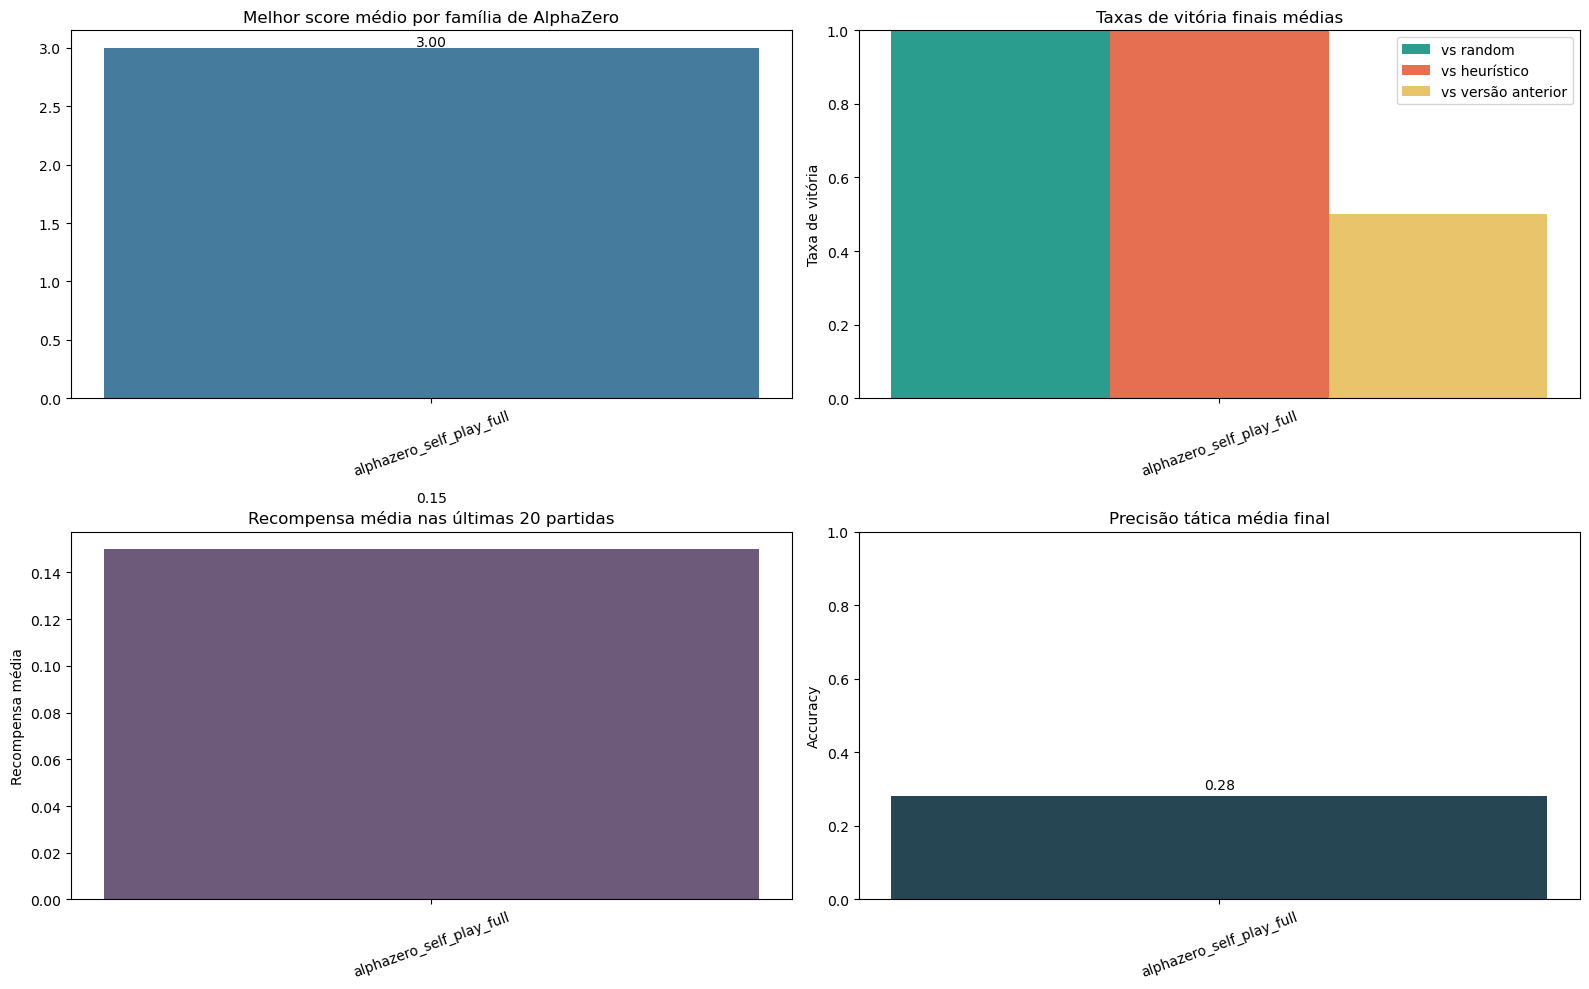

In [6]:
if summary:
    families = list(summary.keys())
    mean_best = [summary[name]["mean_best_score"] for name in families]
    mean_random = [summary[name]["mean_last_vs_random"] for name in families]
    mean_heur = [summary[name]["mean_last_vs_heuristic"] for name in families]
    mean_previous = [summary[name]["mean_last_vs_previous"] for name in families]
    mean_reward = [summary[name]["mean_reward_last_20"] for name in families]
    mean_tactical = [summary[name]["mean_last_tactical_accuracy"] for name in families]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.ravel()

    axes[0].bar(families, mean_best, color="#457b9d")
    axes[0].set_title("Melhor score médio por família de AlphaZero")
    axes[0].tick_params(axis="x", rotation=20)
    for idx, value in enumerate(mean_best):
        axes[0].text(idx, value + 0.02, f"{value:.2f}", ha="center")

    x = list(range(len(families)))
    width = 0.25
    axes[1].bar([value - width for value in x], mean_random, width=width, label="vs random", color="#2a9d8f")
    axes[1].bar(x, mean_heur, width=width, label="vs heurístico", color="#e76f51")
    axes[1].bar([value + width for value in x], mean_previous, width=width, label="vs versão anterior", color="#e9c46a")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(families, rotation=20)
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_title("Taxas de vitória finais médias")
    axes[1].set_ylabel("Taxa de vitória")
    axes[1].legend()

    axes[2].bar(families, mean_reward, color="#6d597a")
    axes[2].set_title("Recompensa média nas últimas 20 partidas")
    axes[2].tick_params(axis="x", rotation=20)
    axes[2].set_ylabel("Recompensa média")
    for idx, value in enumerate(mean_reward):
        axes[2].text(idx, value + 0.02, f"{value:.2f}", ha="center")

    axes[3].bar(families, mean_tactical, color="#264653")
    axes[3].set_title("Precisão tática média final")
    axes[3].tick_params(axis="x", rotation=20)
    axes[3].set_ylim(0.0, 1.0)
    axes[3].set_ylabel("Accuracy")
    for idx, value in enumerate(mean_tactical):
        axes[3].text(idx, value + 0.02, f"{value:.2f}", ha="center")

    fig.tight_layout()
    plt.show()


## Passo 7: Escolha do melhor checkpoint

Nesta célula carregamos o melhor checkpoint disponível do `AlphaZero` com os hiperparâmetros guardados nas métricas do treino.


In [7]:
alphazero_agent = None
best_alphazero_run = find_best_run(ALPHAZERO_OUTPUTS, "alphazero")
if best_alphazero_run is not None:
    checkpoint_path = ROOT / best_alphazero_run.data["best_checkpoint_path"]
    config = best_alphazero_run.config
    best_run = {
        "run_name": best_alphazero_run.metrics_path.parent.name,
        "data": best_alphazero_run.data,
    }
    alphazero_agent = build_agent_from_run(best_alphazero_run, root=ROOT, device=NOTEBOOK_DEVICE)
    print({
        "best_run": best_alphazero_run.metrics_path.parent.name,
        "checkpoint": str(checkpoint_path),
        "n_filters": int(config.get("n_filters", 128)),
        "n_res_blocks": int(config.get("n_res_blocks", 8)),
    })
else:
    print("No AlphaZero runs found under outputs/alphazero/.")


{'best_run': 'alphazero_self_play_full_seed_42', 'checkpoint': '/home/pcabrita/MIA/AR/TP/AR/notebooks/alphazero/outputs/alphazero_self_play_full_seed_42/alphazero_best.pt', 'n_filters': 64, 'n_res_blocks': 4}


### Curvas detalhadas do melhor treino

Esta secção mostra a evolução temporal do melhor treino encontrado. Os gráficos foram separados por objetivo para ser mais fácil perceber se o agente está realmente a melhorar.


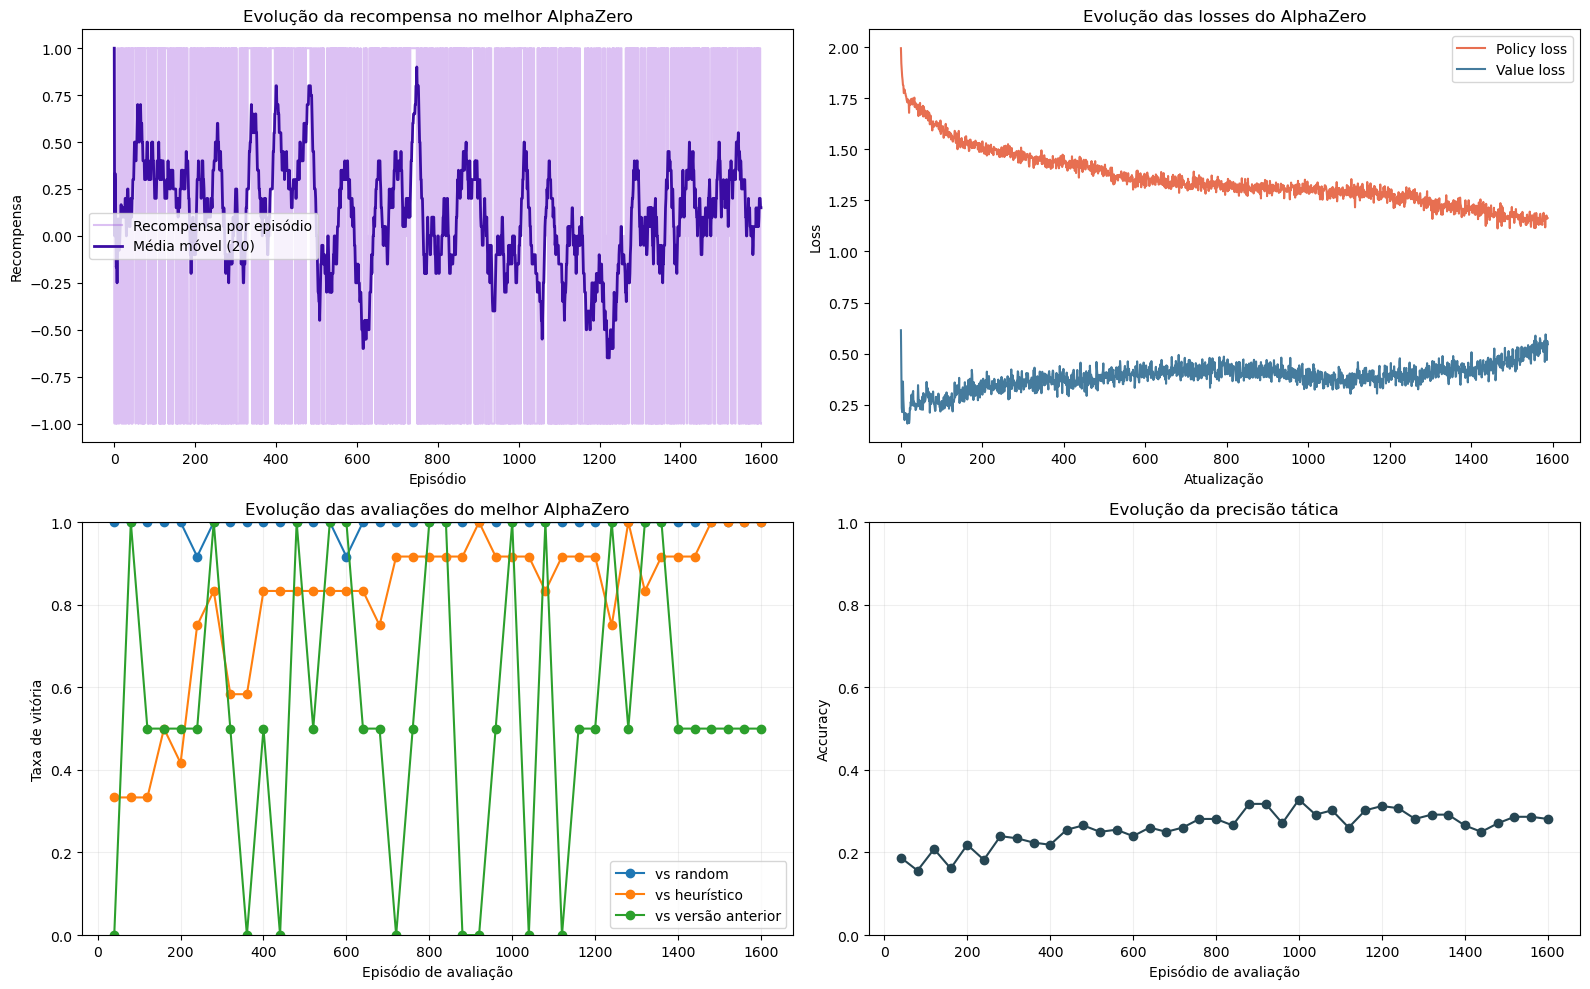

In [8]:
def rolling_mean(values: list[float], window: int = 20) -> list[float]:
    if not values:
        return []
    return [statistics.fmean(values[max(0, idx - window + 1): idx + 1]) for idx in range(len(values))]

if all_runs:
    rewards = [float(value) for value in best_run["data"].get("episode_rewards", [])]
    policy_losses = [float(value) for value in best_run["data"].get("policy_losses", [])]
    value_losses = [float(value) for value in best_run["data"].get("value_losses", [])]
    evaluations = best_run["data"].get("evaluation", [])
    tactical = best_run["data"].get("tactical_accuracy", [])

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.ravel()

    if rewards:
        axes[0].plot(rewards, color="#9d4edd", alpha=0.35, label="Recompensa por episódio")
        axes[0].plot(rolling_mean(rewards, window=20), color="#3a0ca3", linewidth=2, label="Média móvel (20)")
        axes[0].set_title("Evolução da recompensa no melhor AlphaZero")
        axes[0].set_xlabel("Episódio")
        axes[0].set_ylabel("Recompensa")
        axes[0].legend()
    else:
        axes[0].set_title("Sem recompensas registadas")
        axes[0].axis("off")

    if policy_losses or value_losses:
        if policy_losses:
            axes[1].plot(policy_losses, label="Policy loss", color="#e76f51")
        if value_losses:
            axes[1].plot(value_losses, label="Value loss", color="#457b9d")
        axes[1].set_title("Evolução das losses do AlphaZero")
        axes[1].set_xlabel("Atualização")
        axes[1].set_ylabel("Loss")
        axes[1].legend()
    else:
        axes[1].set_title("Sem losses registadas")
        axes[1].axis("off")

    if evaluations:
        eval_episodes = [int(item.get("episode", 0)) for item in evaluations]
        vs_random = [float(item.get("vs_random_win_rate", 0.0)) for item in evaluations]
        vs_heuristic = [float(item.get("vs_heuristic_win_rate", 0.0)) for item in evaluations]
        vs_previous = [float(item.get("vs_previous_win_rate", 0.0)) for item in evaluations]

        axes[2].plot(eval_episodes, vs_random, marker="o", label="vs random")
        axes[2].plot(eval_episodes, vs_heuristic, marker="o", label="vs heurístico")
        axes[2].plot(eval_episodes, vs_previous, marker="o", label="vs versão anterior")
        axes[2].set_ylim(0.0, 1.0)
        axes[2].set_title("Evolução das avaliações do melhor AlphaZero")
        axes[2].set_xlabel("Episódio de avaliação")
        axes[2].set_ylabel("Taxa de vitória")
        axes[2].legend()
        axes[2].grid(alpha=0.2)
    else:
        axes[2].set_title("Sem avaliações registadas")
        axes[2].axis("off")

    if tactical:
        tactical_episodes = [int(item.get("episode", 0)) for item in tactical]
        tactical_values = [float(item.get("accuracy", 0.0)) for item in tactical]
        axes[3].plot(tactical_episodes, tactical_values, marker="o", color="#264653")
        axes[3].set_ylim(0.0, 1.0)
        axes[3].set_title("Evolução da precisão tática")
        axes[3].set_xlabel("Episódio de avaliação")
        axes[3].set_ylabel("Accuracy")
        axes[3].grid(alpha=0.2)
    else:
        axes[3].set_title("Sem avaliação tática registada")
        axes[3].axis("off")

    fig.tight_layout()
    plt.show()


## Passo 8: Torneio entre checkpoints e cálculo de Elo

Se a opção correspondente estiver ativa, esta célula calcula um torneio entre checkpoints do treino e estima o `Elo`.


In [9]:
if alphazero_agent is not None and run_checkpoint_elo:
    checkpoint_files = sorted(checkpoint_path.parent.glob("alphazero_episode_*.pt"))
    step = max(len(checkpoint_files) // 4, 1)
    selected = checkpoint_files[::step][:5]
    if checkpoint_files and checkpoint_files[-1] not in selected:
        selected.append(checkpoint_files[-1])

    checkpoint_factories = {}
    for path in selected:
        label = path.stem.replace("alphazero_episode_", "az_")
        checkpoint_factories[label] = lambda cp=path, cfg=config: build_agent_from_checkpoint(
            "alphazero",
            cp,
            cfg,
            device=NOTEBOOK_DEVICE,
        )

    checkpoint_scores, checkpoint_matches = round_robin_detailed(checkpoint_factories, games_per_pair=24)
    checkpoint_elo = compute_elo_ratings(checkpoint_matches)
    print(checkpoint_scores)
    print(checkpoint_elo)
else:
    print("Set run_checkpoint_elo = True after training to compute AlphaZero checkpoint Elo.")


{'az_0040': {'losses': 72.0, 'games': 96.0, 'wins': 24.0, 'win_rate': 0.25, 'draws': 0.0, 'draw_rate': 0.0}, 'az_0440': {'wins': 36.0, 'games': 96.0, 'losses': 48.0, 'draws': 12.0, 'win_rate': 0.375, 'draw_rate': 0.125}, 'az_0840': {'wins': 36.0, 'games': 96.0, 'losses': 48.0, 'draws': 12.0, 'win_rate': 0.375, 'draw_rate': 0.125}, 'az_1240': {'wins': 48.0, 'games': 96.0, 'losses': 36.0, 'draws': 12.0, 'win_rate': 0.5, 'draw_rate': 0.125}, 'az_1600': {'wins': 72.0, 'games': 96.0, 'losses': 12.0, 'draws': 12.0, 'win_rate': 0.75, 'draw_rate': 0.125}}
{'az_1600': 1514.32, 'az_1240': 1235.65, 'az_0840': 1133.5, 'az_0040': 1115.86, 'az_0440': 1000.67}


## Passo 9: Testes finais e visualização do AlphaZero

Aqui avaliamos o melhor modelo contra os baselines e visualizamos uma partida concreta.


In [10]:
def evaluate_agent(agent, opponent_factory, games: int = 20) -> float:
    wins = 0
    for game_idx in range(games):
        controlled_player = 1 if game_idx % 2 == 0 else 2
        try:
            opponent = opponent_factory(game_idx)
        except TypeError:
            opponent = opponent_factory()
        state = initial_state()
        while not is_terminal(state):
            if state.current_player == controlled_player:
                action = agent.select_action(state, legal_actions(state))
            else:
                action = opponent.select_action(state, legal_actions(state))
            state = apply_action(state, action)
        if state.winner == controlled_player:
            wins += 1
    return wins / games


def play_and_render(agent, opponent, controlled_player: int = 1) -> str:
    state = initial_state()
    transcript = ["Initial board", render_ascii(state), ""]
    move_idx = 0
    while not is_terminal(state):
        move_idx += 1
        if state.current_player == controlled_player:
            action = agent.select_action(state, legal_actions(state))
            actor = agent.name
        else:
            action = opponent.select_action(state, legal_actions(state))
            actor = opponent.name
        state = apply_action(state, action)
        transcript.append(f"Move {move_idx}: {actor} played column {action}")
        transcript.append(render_ascii(state))
        transcript.append("")

    transcript.append(f"Winner: {state.winner}")
    return "\n".join(transcript)

if alphazero_agent is not None:
    summary_eval = {
        "vs_random": evaluate_agent(alphazero_agent, lambda game_idx: RandomAgent(seed=1000 + game_idx), games=20),
        "vs_heuristic": evaluate_agent(alphazero_agent, lambda game_idx: HeuristicAgent(seed=2000 + game_idx), games=20),
        "checkpoint": str(checkpoint_path),
    }
    print(summary_eval)
    print(play_and_render(alphazero_agent, HeuristicAgent(seed=1), controlled_player=1))


{'vs_random': 0.95, 'vs_heuristic': 0.95, 'checkpoint': '/home/pcabrita/MIA/AR/TP/AR/notebooks/alphazero/outputs/alphazero_self_play_full_seed_42/alphazero_best.pt'}
Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: alphazero played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . X . .
0 1 2 3 4 5 6

Move 2: heuristic played column 1
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. O . . X . .
0 1 2 3 4 5 6

Move 3: alphazero played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. O X . X . .
0 1 2 3 4 5 6

Move 4: heuristic played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O . . . .
. O X . X . .
0 1 2 3 4 5 6

Move 5: alphazero played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . X . . . .
. . O . . . .
. O X . X . .
0 1 2 3 4 5 6

Move 6: heuristic played column 1
. . . . . . .
. . . . 

## Passo 10: AlphaZero contra si próprio

No fim, colocamos o melhor agente a jogar contra uma cópia da mesma família de checkpoints.


In [11]:
if alphazero_agent is not None:
    mirror_alphazero = build_agent_from_checkpoint(
        "alphazero",
        checkpoint_path,
        {**config, "seed": int(config.get("seed", 0)) + 1},
        device=NOTEBOOK_DEVICE,
    )
    print(play_and_render(alphazero_agent, mirror_alphazero, controlled_player=1))


Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: alphazero played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . X . .
0 1 2 3 4 5 6

Move 2: alphazero played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O . X . .
0 1 2 3 4 5 6

Move 3: alphazero played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . X . . . .
. . O . X . .
0 1 2 3 4 5 6

Move 4: alphazero played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . X . O . .
. . O . X . .
0 1 2 3 4 5 6

Move 5: alphazero played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . X . . . .
. . X . O . .
. . O . X . .
0 1 2 3 4 5 6

Move 6: alphazero played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . X . O . .
. . X . O . .
. . O . X . .
0 1 2 3 4 5 6

Move 7: alphazero played column 4
. . . . . . .
. . . . . . .
. . . . X . .
. . X . O . .

## Extensão Possível: Curriculum de Oponentes

Uma extensão natural desta linha experimental é testar uma variante híbrida de treino para o `AlphaZero`, alternando o tipo de adversário ao longo do treino.

- início contra `random`, para acelerar padrões táticos simples;
- fase intermédia com mistura de `self-play` e `heuristic`;
- fase final dominada por `self-play`, para recuperar o comportamento mais próximo de `AlphaZero` clássico.

A ideia não foi implementada neste projeto base. Se for explorada, deve ser tratada como uma variante de `AlphaZero` com curriculum de oponentes, e não como a versão clássica pura.


## Fecho

Este notebook deve mostrar de forma clara como a linha `MCTS + rede residual policy/value` foi integrada no projeto e como pode ser avaliada sem duplicar a lógica do jogo no próprio notebook.
